## Esame di Metodi Numerici

21 Luglio 2023

# Esercizio 1
Nel file ``testI.mat`` sono memorizzati la matrice A ed il vettore b. 

 - Verificare che per risolvere il sistema Ax=b sia possibile utilizzare i due metodi di discesa visti a lezione, **Punti 1**
 - implementare entrambi gli algoritmi e dire quante iterazioni sono necessarie per ciascuno di essi  per calcolare la soluzione con una toll=1e-6 e maxit=2000. Visualizzare in un grafico l'errore in scala logaritmica ad ogni iterazione per ciascuno dei due metodi. **Punti 6**
 - Verificare se la matrice è  malcondizionata, dire teoricamente cosa questo implica in termini della velocità di convergenza  dei due metodi alla soluzione, richiamando il risultato teorico visto a lezione.**Punti 2**

 - Costruire la matrice A1, ottenuta a partire da A, sommandole uma matrice diagonale con elementi sulla diagonali tutti uguali a 0.05, e termine noto b1, costruito in maniera tale che la soluzione del sistema A1 x1 =b1 sia il vettore formato da tutti 1. Risolvere il sistema lineare con matrice dei coefficienti A1 e termine noto b1, sia con il metodo del gradiente che con il metodo del gradiente coniugato. Osservare il numero di iterazioni eseguito da ciascun metodo e giustificare i risultati **Punti 2**
  
  **Totale: Punti 11**
   
   
Per la lettura dei dati procedere nel seguente modo:

``from scipy.io import loadmat``

``import numpy as np``

``dati = loadmat('testI.mat')``

``A=dati["A"] ``

``A=A.astype(float)``

`` b=dati["b"] ``

`` b=b.astype(float)``


Condzionamento di A: 10000.000


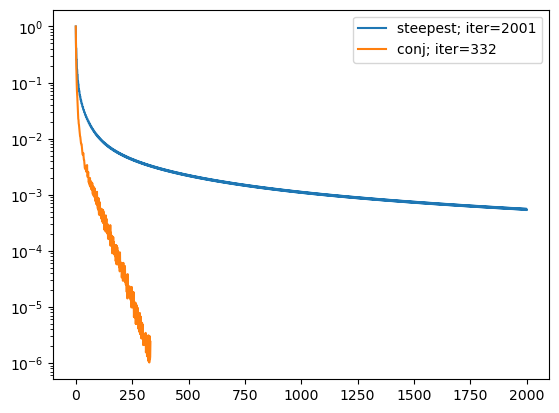

In [13]:
from scipy.io import loadmat

import numpy as np
import numpy.linalg as lin
import scipy.linalg as splin
from itertools import takewhile
import matplotlib.pyplot as plt
from numpy.linalg import matrix_rank as rank
from numpy.linalg import norm

dati = loadmat('testI.mat')
A=dati["A"] 
A=A.astype(float)
b=dati["b"] 
b=b.astype(float).ravel()

print(f'Condzionamento di A: {lin.cond(A):.3f}')
# plt.spy(A)
plt.show()

assert(all(lin.eigvals(A) > 0))
assert(splin.issymmetric(A))

def iterate(func, start):
    while True:
        yield start
        start = func(*start)

def steep(A, b, alfa, dir, toll=1e-6, itmax=2000):
    x0 = np.zeros_like(b)
    r = A @ x0 - b
    err = lambda n,d: norm(n) / norm(d)

    stop_criteria = lambda i, args: i < itmax and err(args[1], b) > toll

    def passo(x, r, p):
        a = alfa(A, r, p)
        nr = r + a * (A.T @ p)
        return x + a*p, nr, dir(nr, r, p)

    iter = iterate(passo, (x0, r, -r))
    arr = list(dict(takewhile(lambda param: stop_criteria(*param), enumerate(iter))).values()) + [next(iter)]

    x_arr = [x for x, _, _ in arr]
    return x_arr[-1], len(x_arr), [err(r, b) for _, r, _ in arr]



def steepest(A, b):
    alfa = lambda A, r, p: (-r.T @ p) / (A.T @ p @ p)
    dir = lambda nr, r, p: -r
    return steep(A, b, alfa, dir)

def conj(A, b):
    alfa = lambda A, r, p: (r.T @ r) / (A.T @ p @ p)
    def dir(nr, r, p):
        gamma = (nr.T @ nr) / (r.T @ r)
        return -nr + (gamma * p)
    return steep(A, b, alfa, dir)


def plot_error(A, b, method, name):
    _, it, err = method(A, b)
    plt.semilogy(range(it), err, label=name + f'; iter={it}')
    plt.legend()

plot_error(A, b, steepest, 'steepest')
plot_error(A, b, conj, 'conj')
plt.show()

# Esercizio 2

Siano assegnati i punti del piano di coordinate $(x_i, y_i)$, $i=1,\ldots,4$ con 
$$
\begin{array}{c}
x_1=0, \quad x_2=5, \quad x_3=0, \quad x_4=6\\
y_1=0, \quad y_2=0, \quad y_3=5, \quad y_4=7.
\end{array}
$$ 
contenenti rispettivamente le ascisse e le ordinate di 11 punti del piano.

 - si costruisca il sistema lineare sovradeterminato ottenuto imponendo il passaggio della circonferenza di equazione $x^2+y^2+a_1x+a_2y+a_3=0$ per i quattro punti assegnati, e si denotino con ${\bf A}$ e ${\bf b}$ la matrice dei coefficienti e il termine noto ottenuti;  **5 punti**

- si sfrutti il metodo  più opportuno per ottenere la soluzione ${\bf a}^*$ del problema ai minimi quadrati $\min_{{\bf a} \in \mathbb{R}^3} \|{\bf A}{\bf a}-{\bf b}\|_2^2$;  **5 punti**

- si calcoli il valore di $\|{\bf A}{\bf a}^*-{\bf b}\|_2^2$ e, dopo averne determinato centro e raggio, si rappresentino in una stessa figura la circonferenza di equazione $x^2+y^2+a^*_1x+a^*_2y+a^*_3=0$ (individuata dalla soluzione ${\bf a}^*$ del problema ai minimi quadrati) e i quattro punti assegnati dal problema. **4 punti**


  **Totale: Punti 14**
**Suggerimento:**
Si ricorda che data una circonferenza nella forma canonica
$$ x^2+y^2+a_1 x+a_2 x+a_3=0$$

le coordinate del suo centro sono 
$$C≡(-a_1/2,-a_2/2)$$

e la lunghezza del suo raggio è data da:

$$r=\sqrt{\frac{a_1^2}{4}+\frac{a_2^2}{4} -a_3}$$

e la circoferenza può essere rappresentata in forma parametrica $C(t),  t \in [0, 2 \cdot \pi]$ e le due componenti parametriche sono $$x(t)= C_0+r\cdot cos(t);$$ $$ y(t)= C_1+r\cdot sin(t)$$


Cond di G (Condizionamento buono) → 8.526

Metodo Singular Value Decomposition (Least Squared)
Condizionamento di A: 8.526

Norma 2 dei minimi quadrati → 57.47126


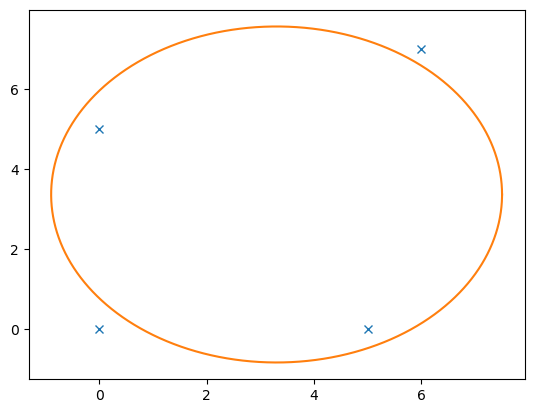

In [115]:
import numpy as np
import scipy as sp
import scipy.linalg as splin
import numpy.linalg as lin
import matplotlib.pyplot as plt
from scipy.linalg import norm
from numpy.linalg import matrix_rank as rank

x=[0,5,0,6]
y=[0,0,5,7]
plt.plot(x, y, 'x')

n = 2
xv = np.linspace(min(x), max(x), 200)
r, c = A.shape


#Usiamo il metodo SVDLS

def SVDLS(A, b):
    U, S, VT = splin.svd(A)
    V = VT.T
    d = U.T @ b
    K = max(S)/min(S)
    print(f"\nMetodo Singular Value Decomposition (Least Squared)\nCondizionamento di A: {K:.3f}\n")
    c = d[:rank(A)] / S[:rank(A)]
    return V[:,:rank(A)] @ c

# regress = np.polyval(np.flip(SVDLS(A, y)), xv)
# plt.plot(xv, regress)

A = np.r_[x, y, np.ones_like(x)].reshape(3, len(x)).T
y = [-(x[i]**2 + y[i]**2) for i in range(len(x))]

print(f'Cond di G (Condizionamento buono) → {lin.cond(A):.3f}')
if rank(A) < c:
    print(f'La matrice non ha rango massimo, dunque eqnorm e qr sono inutilizzabili → {rank(A)} ~ {c}')


a = SVDLS(A, y)

a1, a2, a3 = a

C = lambda a1, a2: (-a1/2,-a2/2)
rag = lambda a1, a2, a3: np.sqrt(a1**2/4 + a2**2/4 - a3)

t = np.arange(0, 2*np.pi, 0.001)
C0, C1 = C(a1, a2)

plt.plot(C0+rag(*a)*np.cos(t), C1+rag(*a)*np.sin(t)) 

print(f'Norma 2 dei minimi quadrati → {norm(A @ a - y)**2:.5f}')

plt.show()


## Domanda intelligenza artificiale

- Allenamento di una rete neurale: dopo aver descritto come è composta una rete neurale, descrivi in cosa consiste la fase di forward propagation e la fase di backward propagation. **Punti: 1**
- Ottimizzazione della loss function per il training di una rete neurale per il task di regressione: Metodo di discesa del gradiente, metodo stocastico del gradiente, metodo del gradiente minibatch.  **Punti 1**  
 - Non convessità della loss-function - come non rimanere bloccati in un monimo locale? Metodo del gradiente con momentum. **Punti 2**
- Learning rate scheduling: step decay, decadimento esponenziale, decadimento dipendente dal tempo. **Punti 1**
 - Learning rate adattivo: Adagrad, RMSProp, Adadelta, Adam. **Punti 2**
 
 **Totale:  7**